# Final Conclusions

1. The January 2026 NYC Yellow Taxi dataset was successfully loaded and explored to understand its structure and contents.

2. The dataset contains trip-level information including pickup/dropoff timestamps, locations, passenger counts, trip distance, fare details, and payment-related attributes.

3. Data quality assessment identified features with missing values that will require appropriate handling in subsequent preprocessing steps.

4. Duplicate records were analyzed to determine whether duplicate removal is necessary before model development.

5. Datetime features (`tpep_pickup_datetime` and `tpep_dropoff_datetime`) were verified and found suitable for temporal analysis and target variable creation.

6. Features available **before ride initiation** were identified as potential predictors, including:
   - `PULocationID`
   - `DOLocationID`
   - `passenger_count`
   - `trip_distance`
   - `tpep_pickup_datetime`

7. Potential data leakage features were identified and will be excluded from model training because they are unavailable before the trip starts, including:
   - `tpep_dropoff_datetime`
   - `tip_amount`
   - `tolls_amount`
   - `total_amount`

8. The `store_and_fwd_flag` feature was determined to have limited predictive value and is not relevant for pre-trip predictions. Therefore, it will be excluded from modeling.

9. Initial exploratory analysis suggests that additional preprocessing steps such as outlier detection, missing value treatment, and feature engineering will be necessary.

10. Based on the data understanding phase, the dataset is suitable for developing machine learning models to predict:
    - Trip Duration
    - Expected Fare Amount

---

## Next Steps

The next notebook will focus on:

- Creating target variables for trip duration and fare prediction.
- Performing data cleaning and validation checks.
- Handling missing values and duplicate records.
- Detecting and treating outliers.
- Preparing the dataset for feature engineering and model development.

---
--

# Use Case 2: Predict Trip Duration and Expected Fare Before Ride Initiation

## Business Problem

Ride-sharing platforms and taxi services often provide riders with estimated trip durations and fare amounts before confirming a booking. Accurate predictions improve customer satisfaction, operational planning, and pricing transparency.

The objective of this project is to develop machine learning models capable of predicting:

1. Trip Duration (in minutes)
2. Fare Amount (in USD)

using only information available before the trip begins.

---

## Objectives

- Understand the January 2026 NYC Yellow Taxi dataset.
- Identify features available before ride initiation.
- Assess data quality and completeness.
- Prepare the dataset for subsequent cleaning and feature engineering stages.

---

## Dataset

Source: NYC TLC Trip Record Data

Dataset Used:

- January 2026 Yellow Taxi Trip Records

Format:

- Parquet File

This notebook focuses exclusively on understanding the dataset structure and assessing its suitability for predictive modeling.

---

# Import Required Libraries

The following libraries are used for:

- Data manipulation and analysis
- Numerical computations
- Visualization
- Display settings

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Configure Display Options

Adjust pandas display settings to improve readability during exploratory analysis.

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Load Dataset

The January 2026 Yellow Taxi dataset is loaded from a parquet file.

Parquet is a columnar storage format optimized for efficient storage and fast analytical queries.

In [3]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE2_Trip_Fare_Forecasting/data/yellow_tripdata_2026-01.parquet"
)

# Dataset Dimensions

Understanding the number of observations and variables provides insight into the scale of the dataset.

- Rows represent taxi trips.
- Columns represent trip attributes.

In [4]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 3,724,889
Number of columns: 20


# Initial Dataset Preview

Inspect the first and last few records to understand:

- Feature names
- Data formats
- Potential anomalies

In [5]:
print("Top 5 Rows:")
df.head()

Top 5 Rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.00,0.97,1.00,N,239,238,1,7.20,1.00,0.50,3.66,0.00,1.00,15.86,2.50,0.00,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.00,0.90,1.00,N,163,162,2,7.90,4.25,0.50,0.00,0.00,1.00,13.65,2.50,0.00,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.00,1.40,1.00,N,43,237,1,10.70,4.25,0.50,2.50,0.00,1.00,18.95,2.50,0.00,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.00,5.58,1.00,N,142,209,1,38.70,1.00,0.50,11.11,0.00,1.00,55.56,2.50,0.00,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.00,2.16,1.00,N,88,144,1,13.50,1.00,0.50,3.85,0.00,1.00,23.10,2.50,0.00,0.75


In [6]:
print("Last Five Rows:")
df.tail()

Last Five Rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,None,237,161,0,17.09,0.00,0.50,0.00,0.00,1.00,21.84,NaN,NaN,0.75
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,None,42,42,0,23.19,0.00,0.50,0.00,0.00,1.00,24.69,NaN,NaN,0.00
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,None,137,69,0,29.21,0.00,0.50,0.00,0.00,1.00,33.96,NaN,NaN,0.75
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,None,137,162,0,19.19,0.00,0.50,0.00,0.00,1.00,23.94,NaN,NaN,0.75
3724888,2,2026-01-31 23:43:12,2026-01-31 23:57:45,NaN,1.04,NaN,None,148,148,0,16.49,0.00,0.50,0.00,0.00,1.00,21.24,NaN,NaN,0.75


In [7]:
df.sample(5, random_state=42)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1511419,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.00,3.90,1.00,N,68,238,1,17.00,3.25,0.50,2.50,0.00,1.00,24.25,2.50,0.00,0.75
3524883,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,NaN,None,69,61,0,49.13,0.00,0.50,0.00,7.46,1.00,58.09,NaN,NaN,0.00
652868,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.00,13.79,1.00,N,13,138,1,55.50,5.00,0.50,19.57,0.00,1.00,84.82,2.50,0.00,0.75
2115729,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.00,1.76,1.00,N,164,79,2,11.40,1.00,0.50,0.00,0.00,1.00,17.15,2.50,0.00,0.75
2645236,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,NaN,None,74,232,0,41.06,0.00,0.50,0.00,0.00,1.00,45.81,NaN,NaN,0.75


# Dataset Structure

The `info()` method provides:

- Column names
- Number of non-null observations
- Data types
- Memory usage

This helps identify:

- Missing values
- Incorrect data types
- Potential preprocessing requirements

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

# Data Dictionary

Understanding each feature is critical before modeling.

The following table summarizes the meaning of each variable.

In [9]:
data_dictionary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values
})

data_dictionary

,Feature,Data Type
0,VendorID,int32
1,tpep_pickup_datetime,datetime64[us]
2,tpep_dropoff_datetime,datetime64[us]
3,passenger_count,float64
4,trip_distance,float64
5,RatecodeID,float64
6,store_and_fwd_flag,object
7,PULocationID,int32
8,DOLocationID,int32
9,payment_type,int64


# Missing Value Analysis

Missing values can negatively impact model performance.

This analysis identifies:

- Which variables contain missing values.
- The proportion of missing observations.
- Features requiring treatment in later stages.

In [10]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage":
    (
        df.isnull().mean() * 100
    ).round(2)
})

missing = missing[
    missing["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

missing

,Missing Count,Missing Percentage
passenger_count,1088058,29.21
RatecodeID,1088058,29.21
store_and_fwd_flag,1088058,29.21
congestion_surcharge,1088058,29.21
Airport_fee,1088058,29.21


# Missing Value Distribution

Visualizing missingness helps prioritize variables requiring attention during preprocessing.

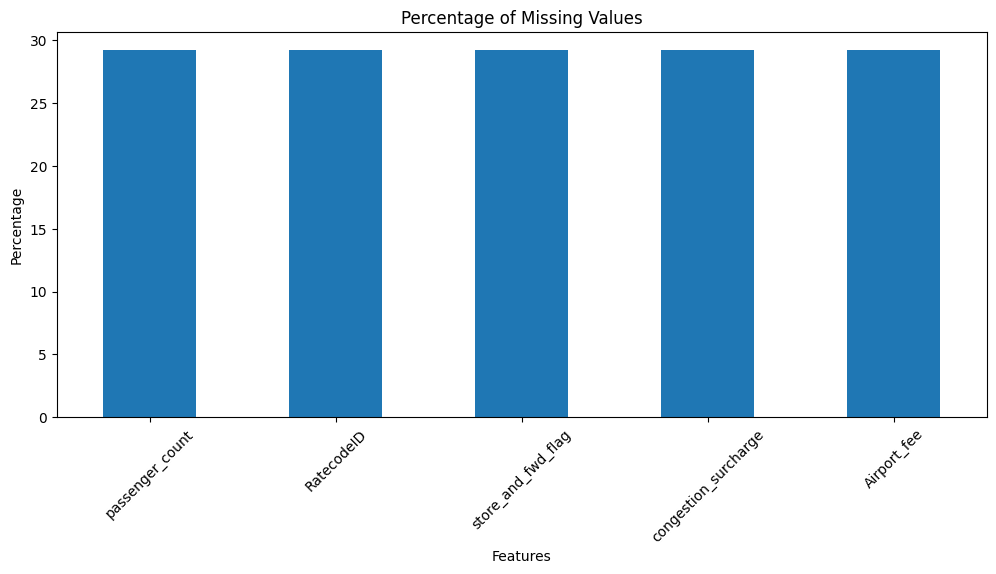

In [ ]:
missing[
    "Missing Percentage"
].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Percentage of Missing Values"
)

plt.ylabel(
    "Percentage"
)

plt.xlabel(
    "Features"
)

plt.xticks(
    rotation=45
)

plt.show()

# Duplicate Record Analysis

Duplicate trips can introduce bias and distort model learning.

This step quantifies duplicate observations present in the dataset.

In [13]:
duplicates = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicates:}"
)

Duplicate rows: 0


# Summary Statistics for Numerical Features

Descriptive statistics provide insights into:

- Central tendency
- Spread
- Potential outliers
- Invalid values

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3724889.00,1.87,1.00,2.00,2.00,2.00,7.00,0.70
tpep_pickup_datetime,3724889,2026-01-17 01:44:52.106518,2025-12-31 23:57:29,2026-01-09 17:51:59,2026-01-16 21:20:56,2026-01-24 07:25:11,2026-02-01 00:45:01,NaN
tpep_dropoff_datetime,3724889,2026-01-17 02:02:03.696138,2025-12-31 23:57:32,2026-01-09 18:08:47,2026-01-16 21:36:14,2026-01-24 07:40:22,2026-02-01 23:35:31,NaN
passenger_count,2636831.00,1.26,0.00,1.00,1.00,1.00,9.00,0.67
trip_distance,3724889.00,6.46,0.00,1.00,1.81,3.73,269097.48,648.89
RatecodeID,2636831.00,5.22,1.00,1.00,1.00,1.00,99.00,19.65
PULocationID,3724889.00,161.44,1.00,114.00,161.00,233.00,265.00,67.07
DOLocationID,3724889.00,160.99,1.00,107.00,162.00,234.00,265.00,71.04
payment_type,3724889.00,0.85,0.00,0.00,1.00,1.00,4.00,0.71
fare_amount,3724889.00,20.80,-2555.20,10.00,15.60,26.10,2555.20,18.93


# Categorical Variable Inspection

Understanding categorical features helps identify:

- Unique values
- Cardinality issues
- Encoding requirements

In [15]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

categorical_cols

Index(['store_and_fwd_flag'], dtype='object')

In [16]:
for col in categorical_cols:
    
    print(f"\n{col}")
    
    print(
        df[col]
        .value_counts()
        .head()
    )


store_and_fwd_flag
store_and_fwd_flag
N    2634494
Y       2337
Name: count, dtype: int64


# DateTime Feature Analysis

Trip timestamps are critical for deriving temporal features such as:

- Hour of day
- Day of week
- Weekend indicator
- Rush hour identification

In [17]:
datetime_cols = df.select_dtypes(
    include=["datetime64[ns]"]
).columns

datetime_cols

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime'], dtype='object')

In [18]:
for col in datetime_cols:
    
    print(f"\n{col}")
    
    print(
        "Min:",
        df[col].min()
    )
    
    print(
        "Max:",
        df[col].max()
    )


tpep_pickup_datetime
Min: 2025-12-31 23:57:29
Max: 2026-02-01 00:45:01

tpep_dropoff_datetime
Min: 2025-12-31 23:57:32
Max: 2026-02-01 23:35:31


# Feature Relevance for Prediction

Only features available before ride initiation should be used for prediction.

Features generated after trip completion introduce data leakage and must be excluded.

In [19]:
available_before_trip = [

    "PULocationID",

    "DOLocationID",

    "passenger_count",

    "trip_distance",

    "tpep_pickup_datetime"
]

leakage_features = [

    "tpep_dropoff_datetime",

    "tip_amount",

    "tolls_amount",

    "total_amount"
]

print(
    "Useful Features:"
)

print(
    available_before_trip
)

print(
    "\nPotential Leakage Features:"
)

print(
    leakage_features
)

Useful Features:
['PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'tpep_pickup_datetime']

Potential Leakage Features:
['tpep_dropoff_datetime', 'tip_amount', 'tolls_amount', 'total_amount']


# Initial Observations

## Key Findings

1. The dataset contains approximately X million taxi trips.

2. Several variables contain missing values and will require treatment.

3. Datetime variables appear correctly parsed.

4. Certain features such as `tip_amount` and `total_amount` are unavailable before ride completion and will be excluded from modeling.

5. Numerical variables exhibit large ranges, suggesting the presence of outliers that will require investigation during data cleaning.

6. The dataset contains geographic pickup and dropoff identifiers suitable for spatial feature engineering.

---

## Next Steps

The next notebook will focus on:

- Target variable creation
- Data cleaning
- Outlier handling
- Validation rule implementation